In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [104]:
class Test:
    def __init__(self, df):
        self.df = df
        self.id = df['participant_ID'][0]
        self.date = df['visit_date'][0]
        self.df['Stage'] = self.df[self.df['Phase'] == 'EXERCISE'].groupby(['Speed','Grade']).ngroup() + 1
        #max_stage = self.df['Stage'].max()
        #self.df.loc[self.df['Phase'] == 'WARMUP', 'Stage'] = 0
        #self.df.loc[self.df['Phase'] == 'RECOVERY', 'Stage'] = max_stage + 1
        self.lactate_df = self.df.dropna(subset=['La-', 'Stage'])[['La-', 'Phase', 't', 'Speed', 'Grade', 'Stage']] 

    def lactate_graph(self):
        plt.plot(self.lactate_df['Speed'], self.lactate_df['La-'])
        plt.xlabel('Time')
        plt.ylabel('Lactate')
        plt.title('Lactate vs Time')
        LT1ref, LT2ref = self.lt_ref_vals()
        plt.axvline(x=LT1ref, color='r')
        plt.axvline(x=LT2ref, color='g', linestyle='--')
        plt.show()
    
    def lt_ref_vals(self):
        lt1ref_index = (self.lactate_df['La-'].diff() > 0.5).idxmax()
        LT1ref = self.lactate_df.loc[lt1ref_index, 'Speed']
        lt2ref_index = (self.lactate_df['La-'].diff() > 1).idxmax()
        LT2ref = self.lactate_df.loc[lt2ref_index, 'Speed']
        return LT1ref, LT2ref
        
        
        

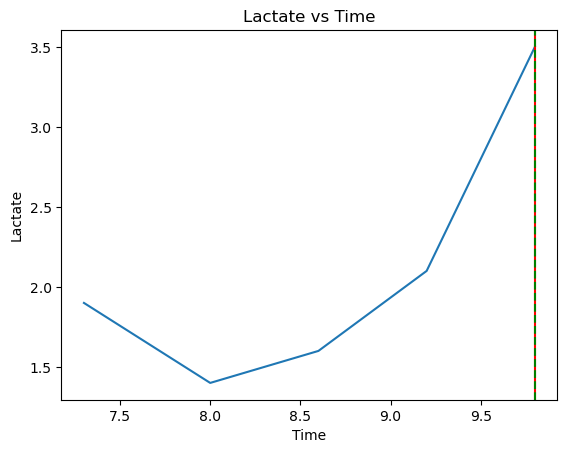

(9.8, 9.8)

In [107]:
df = pd.read_csv('visit_data/TR000100_20220331_visit_data.csv')
test = Test(df)
test.lactate_graph()
test.lt_ref_vals()
